<a href="https://colab.research.google.com/github/Palbanks12/insurance-charge-analysis./blob/main/Python_Final_Project_Paul_Bankole_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Insurance Charges Analysis**

**Project Scenario **

You are a Junior Data Analyst at a health insurance company. The company has provided you with a dataset of customers’ demographic and health information along with their medical insurance charges.
Your task is to:
- Clean and prepare the dataset,
- Explore and analyse relationships between features and insurance charges,
- Create meaningful visualisations using Pandas, Matplotlib, and Seaborn,
- Summarise your findings and present them to your manager.

Dataset Overview
The dataset contains the following key columns:
- age → Age of the insured person.
- sex → Gender of the insured person (male, female).
- bmi → Body Mass Index (an indicator of body fat based on height and weight).
- children → Number of children/dependents covered by the insurance.
 - smoker → Whether the person is a smoker (yes, no).
- region → Residential region of the insured (northwest, southeast, etc.).
 - charges → Medical insurance cost billed to the individual.

Business Context:
The company wants to identify which factors influence insurance charges the most (e.g.,  age, BMI, smoking status).
These insights will help in pricing policies and advising  customers.


**Project Steps**

**Step:1 Import & Inspect the Data**

Instructions:

Import Pandas.

*   Load insurance.csv into a DataFrame named df.
*   Use head() to display the first few rows.
*   Use info() to check data types and missing values.
*   Use describe() to see summary statistics.





In [ ]:
# TODO: import pandas and load the CSV file
import pandas as pd

# Load the dataset
df = pd.read_csv('insurance.csv')

# View the first 5 rows
display(df.head())


# Check data types and non-null counts
display(df.info())


# Check data number of records
display(df.shape)


# View summary statistics
display(df.describe())




print(df.columns.tolist())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

(1338, 7)

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


**Step 2: Data Cleaning**

Instructions:


*   Check for missing values and duplicates.
*   Drop duplicates if necessary.
*   Ensure correct  data types.


In [ ]:
#TODO:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicate rows
print('\nNumber of duplicate rows:')
print(df.duplicated().sum())

# Drop duplicate rows
df = df.drop_duplicates()
print(f"Remaining rows: {len(df)}")

# Check data types
print('\nData types:')
print(df.dtypes)

# Convert columns to correct types
df['age'] = df['age'].astype(int)
df['bmi'] = df['bmi'].astype(float)
df['children'] = df['children'].astype(int)
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')
df['charges'] = df['charges'].astype(float)
print("\nUpdated data types:")
print(df.dtypes)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows:
1
Remaining rows: 1337

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Updated data types:
age            int64
sex           object
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object


**Step 3: Data Exploration (EDA)**

Instructions:



*   Find average, minimum, and maximum charges.
*   Count smokers vs non-smokers.
*   Compare charges by gender, region, children.

In [ ]:
# TODO:
# Calculate average, minimum, and maximum charges
average_charge = df['charges'].mean()
min_charge = df['charges'].min()
max_charge = df['charges'].max()
print(f"Average charge: ${average_charge:.2f}")
print(f"Minimum charge: ${min_charge:.2f}")
print(f"Maximum charge: ${max_charge:.2f}")

# Count smokers vs non-smokers.
smoker_counts = df['smoker'].value_counts()
print("\nSmoker vs Non-smoker counts:")
print(smoker_counts)

# Compare charges by gender, region, children.
print("\nCharges by gender:")
print(df.groupby('sex')['charges'].mean())

print("\nCharges by region:")
print(df.groupby('region')['charges'].mean())

print("\nCharges by number of children:")
print(df.groupby('children')['charges'].mean())

Average charge: $13279.12
Minimum charge: $1121.87
Maximum charge: $63770.43

Smoker vs Non-smoker counts:
smoker
no     1063
yes     274
Name: count, dtype: int64

Charges by gender:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

Charges by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Charges by number of children:
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


/tmp/ipython-input-773635559.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('region')['charges'].mean())


**Step 4: Data Transformation**

Instructions:



*   Create bmi_category (Underweight, Normal, Overweight, Obese).
*   Create age_group  (Young, Middle-aged, Senior).

In [ ]:
# TODO:
# Create bmi_category (Underweight, Normal, Overweight, Obese).
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')],
labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print(df['bmi_category']. value_counts())

# Create age_group (Young, Middle-aged, Senior).
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, float('inf')],
labels=['Young', 'Middle-aged', 'Senior'])
print(df['age_group']. value_counts())

bmi_category
Obese          715
Overweight     380
Normal         221
Underweight     21
Name: count, dtype: int64
age_group
Middle-aged    803
Young          443
Senior          91
Name: count, dtype: int64


**Step 5: Visualisation with Matplotlib**

Instructions:



*   Create bar chart (average charges by region),
*   line chart (average charges by age), List item
*   pie  chart (smoker vs non-smoker).

/tmp/ipython-input-2754177154.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_charges_by_region = df.groupby('region')['charges'].mean()


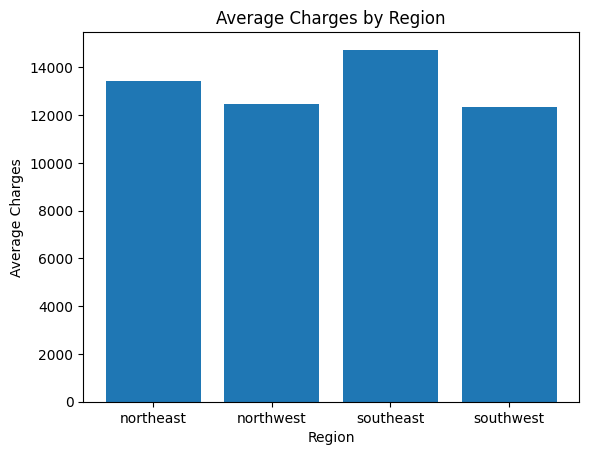

/tmp/ipython-input-2754177154.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_charges_by_age = df.groupby('age_group')['charges'].mean()


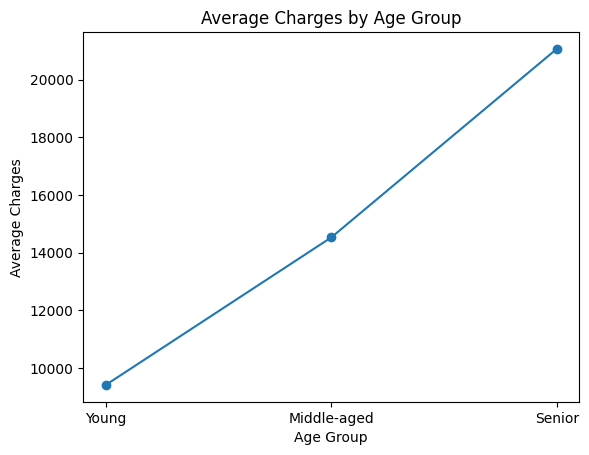

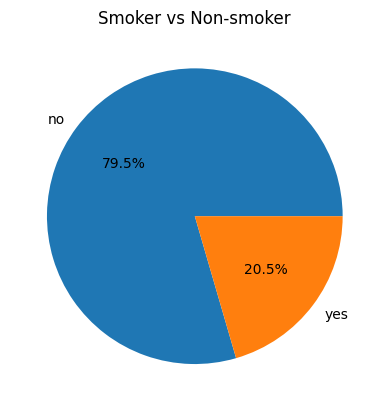

In [ ]:
# TODO:
import matplotlib.pyplot as plt

# Create bar chart (average charges by region),
average_charges_by_region = df.groupby('region')['charges'].mean()
plt.bar(average_charges_by_region.index, average_charges_by_region.values)
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.title('Average Charges by Region')
plt.show()

# line chart (average charges by age),
average_charges_by_age = df.groupby('age_group')['charges'].mean()
plt.plot(average_charges_by_age.index, average_charges_by_age.values, marker='o')
plt.xlabel('Age Group')
plt.ylabel('Average Charges')
plt.title('Average Charges by Age Group')
plt.show()

# Pie chart (smoker vs non-smoker).
smoker_counts = df['smoker'].value_counts()
plt.pie(smoker_counts.values, labels=smoker_counts.index, autopct='%1.1f%%')
plt.title('Smoker vs Non-smoker')
plt.show()

**Step 6: Visualisation with Seaborn**

Instructions:



*   Create histogram (charges),
*   Boxplot (smoker vs non-smoker),
*   Scatter plot (BMI vs  charges),
*   Heatmap (correlations).

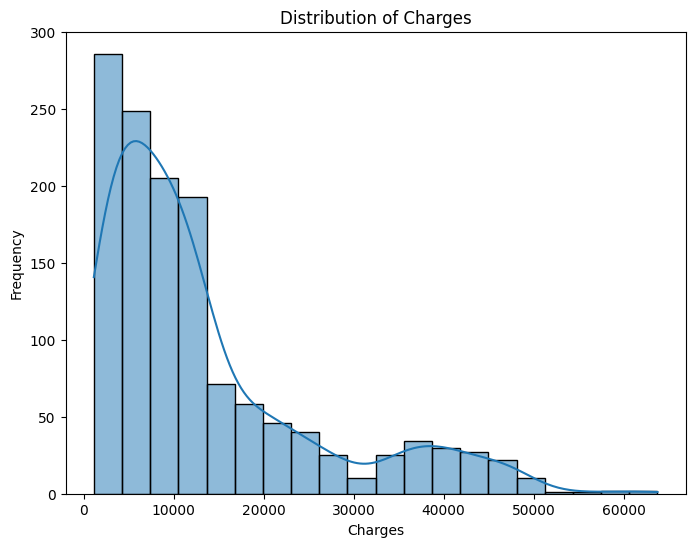

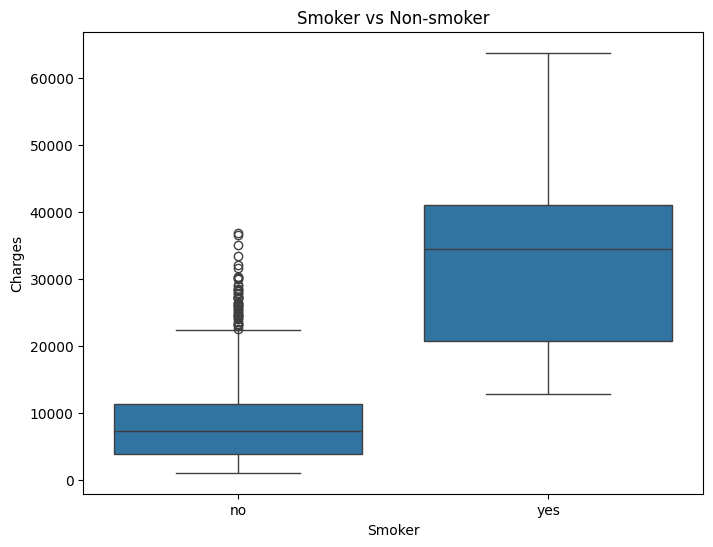

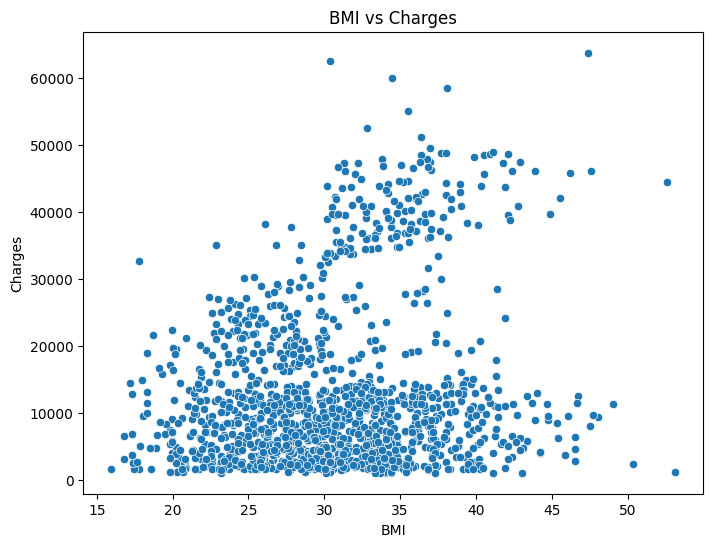

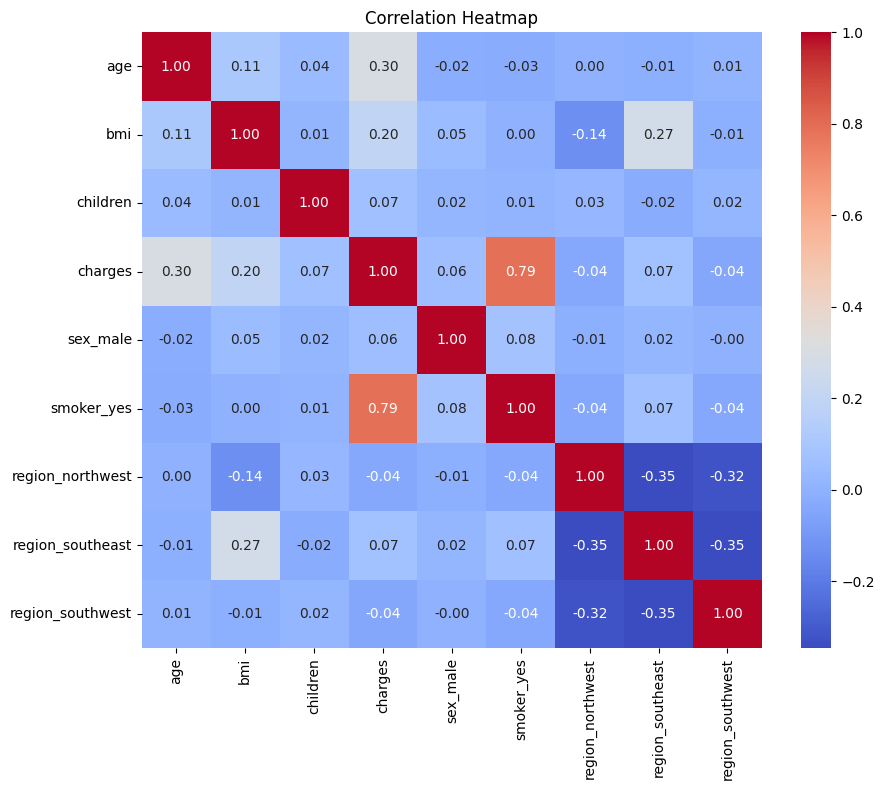

In [ ]:
# TODO:
import seaborn as sns
import matplotlib.pyplot as plt

# Create histogram (charges).
plt.figure(figsize=(8, 6))
sns.histplot(df['charges'], bins=20, kde=True)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

# Boxplot (smoker vs non-smoker),
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.title('Smoker vs Non-smoker')
plt.show()

# Scatter plot (BMI vs charges),
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges')
plt.show()

# Create Heatmap (correlations).
# Convert categorical columns to numeric using one-hot encoding and exclude non-numeric columns
df_encoded = pd.get_dummies(df.drop(columns=['bmi_category', 'age_group']), columns=['sex', 'smoker', 'region'], drop_first=True)

correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Step 7: Business Insights & Reflection**

**Summarise findings:**


*   smokers vs non-smokers,
*   BMI effect,
*   age impact,
*   regional  differences.

**Reflection question:**


If you were advising the company,

1. Which three factors are the strongest drivers of charges and
2. Why?

**Answer:**

Based on the analysis and visualizations, the three strongest drivers of insurance charges are:

1.  **Smoking Status:** Smokers have significantly higher charges due to increased health risks and associated medical costs.
2.  **Age:** Older individuals tend to have higher charges as the likelihood of developing health conditions increases with age.
3.  **BMI:** Higher BMI is associated with increased charges, likely due to related health issues such as heart disease and diabetes.

These factors show the strongest positive correlations with insurance charges in this dataset.

In [ ]:
# TODO: Save cleaned dataset to a new CSV file
df.to_csv('cleaned_insurance.csv', index=False)